DATASET INFORMATION
Dataset shape: (50000, 3)
X shape: (50000,)
y shape: (50000,)

Target distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Training samples: 40000
Testing samples : 10000

LOADED ARTIFACTS
Model     : LogisticRegression
Vectorizer: TfidfVectorizer

Vectorized test shape: (10000, 20000)

FINAL MODEL PERFORMANCE
Accuracy : 0.9196
Precision: 0.9086
Recall   : 0.9330
F1 Score : 0.9207

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    negative       0.93      0.91      0.92      5000
    positive       0.91      0.93      0.92      5000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000


CONFUSION MATRIX
[[4531  469]
 [ 335 4665]]

True Negative : 4531
False Positive: 469
False Negative: 335
True Positive : 4665


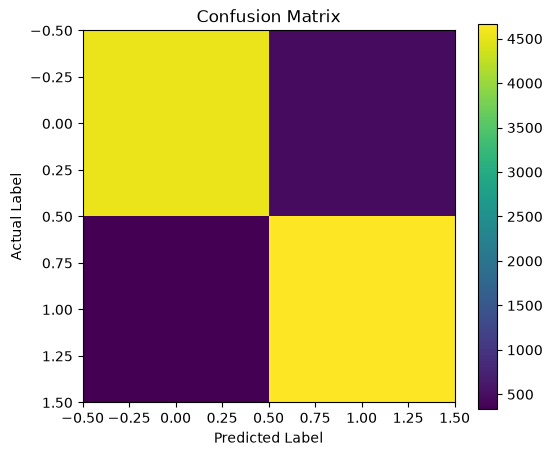


Model classes:
['negative' 'positive']

PREDICTION SUMMARY
Total test samples: 10000
Correct predictions: 9196
Incorrect predictions: 804
Validation accuracy: 0.9196

SAMPLE MISCLASSIFIED REVIEWS
----------------------------------------------------------------------
Actual    : negative
Predicted : positive
Confidence: 0.6646

Review:
ability enjoy ash time may depend expectation stepping theater even strident supporter seem agree audience split right middle appreciation unique hk actioners battle scene curiously kept distance happen rendered jerky style difficult make exactly occurring screen dramatic scene extravagantly beautiful maggie cheung brigitte lin hk top acting talent chewing scenery wong early work dialog could precise short ash time requires forgiving attitude released around time wong spectacularly successful chungking express clear director confident working element martial art film anyone looking tense action likely disappointed intrigued director aesthetic likely find

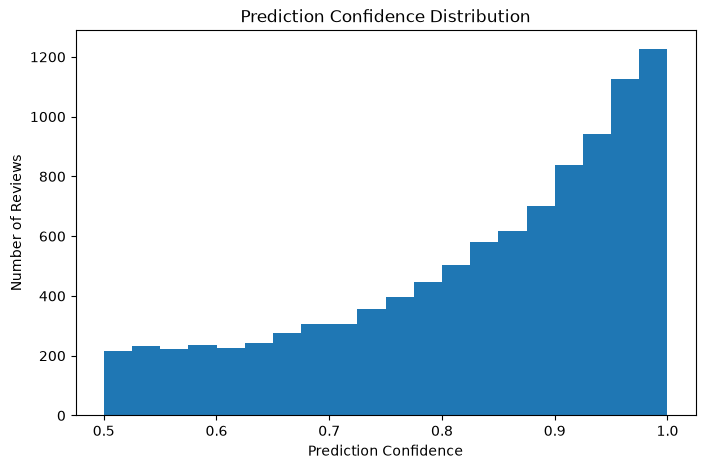

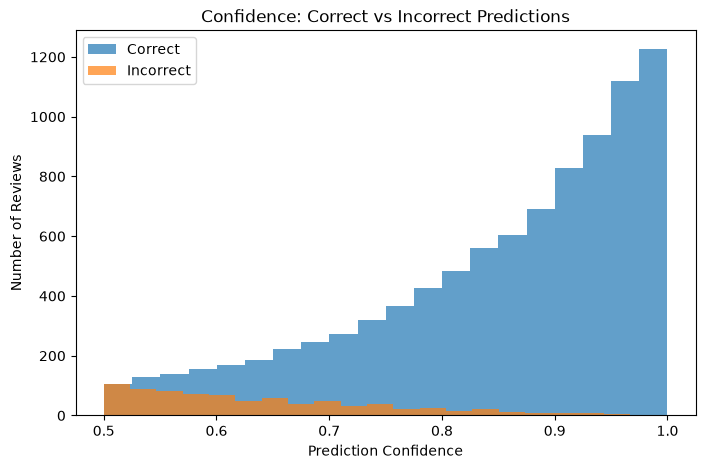


TOP POSITIVE FEATURES
          feature  coefficient
7456        great     7.474993
5384    excellent     6.864814
13263     perfect     5.590352
635       amazing     4.860278
19587   wonderful     4.838629
1575         best     4.604882
10115       loved     4.517671
7998    hilarious     4.435859
5731     favorite     4.283172
6717          fun     4.149117
2016    brilliant     4.126568
12589    one best     4.104461
5002      enjoyed     4.043232
18100       today     4.038919
3977   definitely     3.863558
17228      superb     3.843269
4997    enjoyable     3.790699
10084        love     3.630154
16860       still     3.516406
5650    fantastic     3.494620

TOP NEGATIVE FEATURES
             feature  coefficient
19676          worst    -9.474735
1252             bad    -8.249138
1186           awful    -7.783152
19109          waste    -7.145152
1899          boring    -6.350398
13674           poor    -5.910178
17604       terrible    -5.685051
12363        nothing    -5.3293

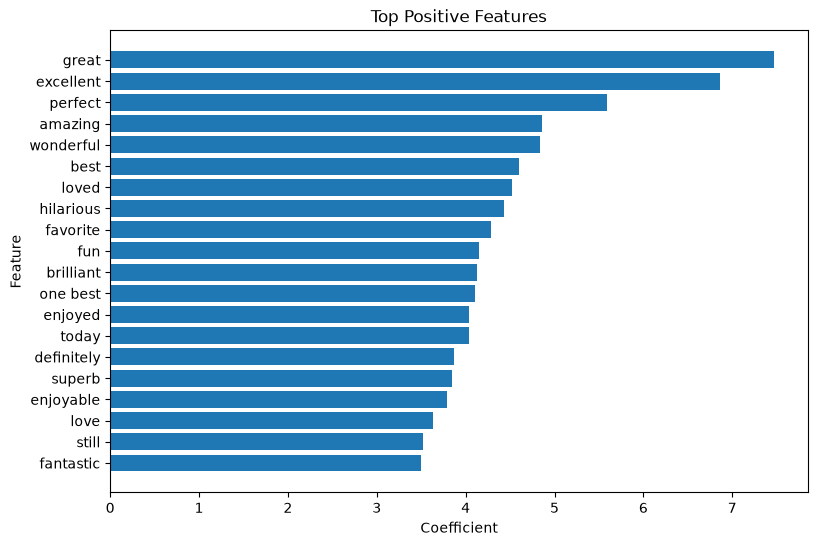

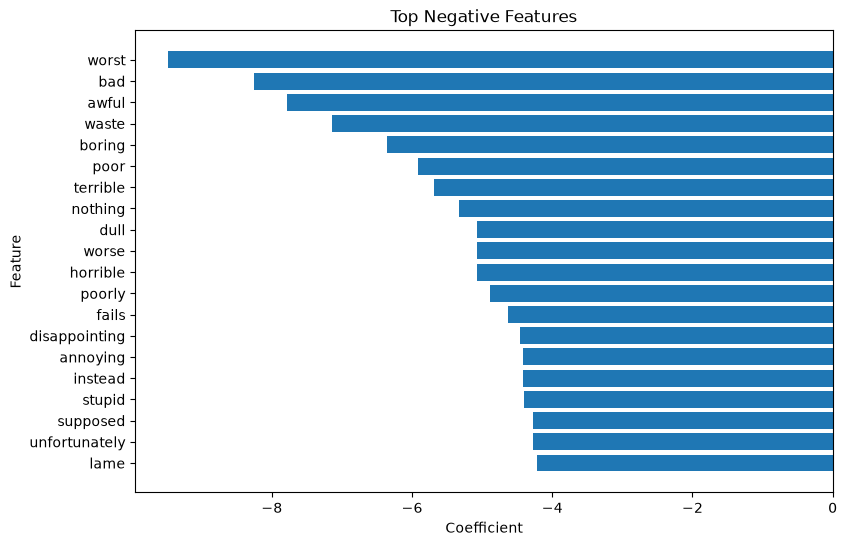


MODEL SUMMARY
                       Metric         Value
0                    Accuracy      0.919600
1                   Precision      0.908648
2                      Recall      0.933000
3                    F1 Score      0.920663
4                Test Samples  10000.000000
5          Number of Features  20000.000000
6       Incorrect Predictions    804.000000
7      High Confidence Errors     19.000000
8  Low Confidence Predictions    904.000000

ARTIFACT CHECK
tfidf_vectorizer.pkl                     : True
sentiment_model.pkl                      : True
validation_predictions.csv               : True
model_errors.csv                         : True
high_confidence_errors.csv               : True
model_validation_summary.csv             : True
validation_summary.pkl                   : True

MODEL VALIDATION COMPLETED
Accuracy : 0.9196
Precision: 0.9086
Recall   : 0.9330
F1 Score : 0.9207

Final model: LogisticRegression
Final vectorizer: TfidfVectorizer
Number of features: 20000


In [2]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


# ============================================================
# 1. LOAD PROCESSED DATASET
# ============================================================

df = pd.read_csv(
    "../../data/processed/processed_reviews.csv"
)

X = df["clean_text"]
y = df["sentiment"]

print("=" * 70)
print("DATASET INFORMATION")
print("=" * 70)

print("Dataset shape:", df.shape)
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())


# ============================================================
# 2. TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=43,
    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Testing samples :", len(X_test))


# ============================================================
# 3. LOAD FINAL MODEL AND VECTORIZER
# ============================================================

vectorizer = joblib.load(
    "../artifacts/tfidf_vectorizer.pkl"
)

model = joblib.load(
    "../artifacts/sentiment_model.pkl"
)

print("\n" + "=" * 70)
print("LOADED ARTIFACTS")
print("=" * 70)

print("Model     :", type(model).__name__)
print("Vectorizer:", type(vectorizer).__name__)


# ============================================================
# 4. VECTORIZE TEST DATA
# ============================================================

X_test_vectorized = vectorizer.transform(
    X_test
)

print(
    "\nVectorized test shape:",
    X_test_vectorized.shape
)


# ============================================================
# 5. GENERATE PREDICTIONS
# ============================================================

y_pred = model.predict(
    X_test_vectorized
)

y_probability = model.predict_proba(
    X_test_vectorized
)


# ============================================================
# 6. MODEL METRICS
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    pos_label="positive"
)

recall = recall_score(
    y_test,
    y_pred,
    pos_label="positive"
)

f1 = f1_score(
    y_test,
    y_pred,
    pos_label="positive"
)


# ============================================================
# 7. FINAL PERFORMANCE
# ============================================================

print("\n" + "=" * 70)
print("FINAL MODEL PERFORMANCE")
print("=" * 70)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")


# ============================================================
# 8. CLASSIFICATION REPORT
# ============================================================

print("\n" + "=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_test,
        y_pred
    )
)


# ============================================================
# 9. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\n" + "=" * 70)
print("CONFUSION MATRIX")
print("=" * 70)

print(cm)


# Binary classification
tn, fp, fn, tp = cm.ravel()

print("\nTrue Negative :", tn)
print("False Positive:", fp)
print("False Negative:", fn)
print("True Positive :", tp)


# ============================================================
# 10. CONFUSION MATRIX VISUALIZATION
# ============================================================

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.colorbar()

plt.show()


# ============================================================
# 11. CREATE VALIDATION DATAFRAME
# ============================================================

validation_df = pd.DataFrame({
    "review": X_test.values,
    "actual": y_test.values,
    "predicted": y_pred
})


# ============================================================
# 12. CLASS PROBABILITIES
# ============================================================

print("\nModel classes:")

print(model.classes_)

negative_index = list(
    model.classes_
).index("negative")

positive_index = list(
    model.classes_
).index("positive")


validation_df["negative_probability"] = (
    y_probability[:, negative_index]
)

validation_df["positive_probability"] = (
    y_probability[:, positive_index]
)


# ============================================================
# 13. PREDICTION CONFIDENCE
# ============================================================

validation_df["confidence"] = np.where(
    validation_df["predicted"] == "positive",
    validation_df["positive_probability"],
    validation_df["negative_probability"]
)


# ============================================================
# 14. CORRECT / INCORRECT PREDICTIONS
# ============================================================

validation_df["correct"] = (
    validation_df["actual"]
    ==
    validation_df["predicted"]
)


# ============================================================
# 15. UNCERTAINTY
# ============================================================

validation_df["uncertainty"] = abs(
    validation_df["confidence"] - 0.5
)


# ============================================================
# 16. CORRECT PREDICTIONS
# ============================================================

correct_predictions = validation_df[
    validation_df["correct"]
]

print("\n" + "=" * 70)
print("PREDICTION SUMMARY")
print("=" * 70)

print(
    "Total test samples:",
    len(validation_df)
)

print(
    "Correct predictions:",
    len(correct_predictions)
)


# ============================================================
# 17. INCORRECT PREDICTIONS
# ============================================================

errors = validation_df[
    ~validation_df["correct"]
].copy()

print(
    "Incorrect predictions:",
    len(errors)
)


# ============================================================
# 18. VALIDATION ACCURACY
# ============================================================

validation_accuracy = (
    validation_df["correct"].mean()
)

print(
    "Validation accuracy:",
    round(validation_accuracy, 4)
)


# ============================================================
# 19. SAMPLE MISCLASSIFIED REVIEWS
# ============================================================

print("\n" + "=" * 70)
print("SAMPLE MISCLASSIFIED REVIEWS")
print("=" * 70)

for _, row in errors.head(10).iterrows():

    print("-" * 70)

    print("Actual    :", row["actual"])
    print("Predicted :", row["predicted"])
    print(
        "Confidence:",
        round(row["confidence"], 4)
    )

    print("\nReview:")
    print(row["review"])


# ============================================================
# 20. HIGH-CONFIDENCE ERRORS
# ============================================================

high_confidence_errors = errors[
    errors["confidence"] >= 0.90
].copy()

print("\n" + "=" * 70)
print("HIGH-CONFIDENCE ERRORS")
print("=" * 70)

print(
    "Number of high-confidence errors:",
    len(high_confidence_errors)
)


for _, row in high_confidence_errors.head(10).iterrows():

    print("-" * 70)

    print("Actual    :", row["actual"])
    print("Predicted :", row["predicted"])
    print(
        "Confidence:",
        round(row["confidence"], 4)
    )

    print("\nReview:")
    print(row["review"])


# ============================================================
# 21. LOW-CONFIDENCE PREDICTIONS
# ============================================================

low_confidence = validation_df[
    validation_df["confidence"] < 0.60
].copy()

print("\n" + "=" * 70)
print("LOW-CONFIDENCE PREDICTIONS")
print("=" * 70)

print(
    "Number of low-confidence predictions:",
    len(low_confidence)
)


# ============================================================
# 22. MOST UNCERTAIN PREDICTIONS
# ============================================================

most_uncertain = validation_df.sort_values(
    "uncertainty"
)

print("\n" + "=" * 70)
print("MOST UNCERTAIN PREDICTIONS")
print("=" * 70)

for _, row in most_uncertain.head(10).iterrows():

    print("-" * 70)

    print("Actual    :", row["actual"])
    print("Predicted :", row["predicted"])
    print(
        "Confidence:",
        round(row["confidence"], 4)
    )

    print("\nReview:")
    print(row["review"])


# ============================================================
# 23. ERROR RATE BY CLASS
# ============================================================

error_by_class = (
    validation_df
    .groupby("actual")["correct"]
    .apply(lambda x: 1 - x.mean())
)

print("\n" + "=" * 70)
print("ERROR RATE BY CLASS")
print("=" * 70)

print(
    (error_by_class * 100).round(2)
)


# ============================================================
# 24. ACCURACY BY CLASS
# ============================================================

accuracy_by_class = (
    validation_df
    .groupby("actual")["correct"]
    .mean()
)

print("\n" + "=" * 70)
print("ACCURACY BY CLASS")
print("=" * 70)

print(
    accuracy_by_class.round(4)
)


# ============================================================
# 25. ACTUAL VS PREDICTED DISTRIBUTION
# ============================================================

print("\n" + "=" * 70)
print("ACTUAL VS PREDICTED DISTRIBUTION")
print("=" * 70)

distribution = pd.DataFrame({
    "Actual": y_test.value_counts(),
    "Predicted": pd.Series(
        y_pred
    ).value_counts()
})

print(distribution)


# ============================================================
# 26. CONFIDENCE DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 5))

plt.hist(
    validation_df["confidence"],
    bins=20
)

plt.xlabel("Prediction Confidence")
plt.ylabel("Number of Reviews")
plt.title("Prediction Confidence Distribution")

plt.show()


# ============================================================
# 27. CORRECT VS INCORRECT CONFIDENCE
# ============================================================

plt.figure(figsize=(8, 5))

plt.hist(
    validation_df[
        validation_df["correct"]
    ]["confidence"],
    bins=20,
    alpha=0.7,
    label="Correct"
)

plt.hist(
    validation_df[
        ~validation_df["correct"]
    ]["confidence"],
    bins=20,
    alpha=0.7,
    label="Incorrect"
)

plt.xlabel("Prediction Confidence")
plt.ylabel("Number of Reviews")

plt.title(
    "Confidence: Correct vs Incorrect Predictions"
)

plt.legend()

plt.show()


# ============================================================
# 28. LOGISTIC REGRESSION FEATURE ANALYSIS
# ============================================================

feature_names = (
    vectorizer.get_feature_names_out()
)

coefficients = model.coef_[0]

coefficient_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})


# ============================================================
# 29. TOP POSITIVE FEATURES
# ============================================================

positive_features = (
    coefficient_df
    .sort_values(
        "coefficient",
        ascending=False
    )
    .head(20)
)

print("\n" + "=" * 70)
print("TOP POSITIVE FEATURES")
print("=" * 70)

print(positive_features)


# ============================================================
# 30. TOP NEGATIVE FEATURES
# ============================================================

negative_features = (
    coefficient_df
    .sort_values(
        "coefficient",
        ascending=True
    )
    .head(20)
)

print("\n" + "=" * 70)
print("TOP NEGATIVE FEATURES")
print("=" * 70)

print(negative_features)


# ============================================================
# 31. POSITIVE FEATURE PLOT
# ============================================================

plt.figure(figsize=(9, 6))

plt.barh(
    positive_features["feature"],
    positive_features["coefficient"]
)

plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Top Positive Features")

plt.gca().invert_yaxis()

plt.show()


# ============================================================
# 32. NEGATIVE FEATURE PLOT
# ============================================================

plt.figure(figsize=(9, 6))

plt.barh(
    negative_features["feature"],
    negative_features["coefficient"]
)

plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Top Negative Features")

plt.gca().invert_yaxis()

plt.show()


# ============================================================
# 33. MODEL SUMMARY
# ============================================================

model_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Test Samples",
        "Number of Features",
        "Incorrect Predictions",
        "High Confidence Errors",
        "Low Confidence Predictions"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        f1,
        len(y_test),
        X_test_vectorized.shape[1],
        len(errors),
        len(high_confidence_errors),
        len(low_confidence)
    ]
})

print("\n" + "=" * 70)
print("MODEL SUMMARY")
print("=" * 70)

print(model_summary)


# ============================================================
# 34. CREATE ARTIFACT DIRECTORY
# ============================================================

os.makedirs(
    "../artifacts",
    exist_ok=True
)


# ============================================================
# 35. SAVE VALIDATION PREDICTIONS
# ============================================================

validation_df.to_csv(
    "../artifacts/validation_predictions.csv",
    index=False
)


# ============================================================
# 36. SAVE MODEL ERRORS
# ============================================================

errors.to_csv(
    "../artifacts/model_errors.csv",
    index=False
)


# ============================================================
# 37. SAVE HIGH-CONFIDENCE ERRORS
# ============================================================

high_confidence_errors.to_csv(
    "../artifacts/high_confidence_errors.csv",
    index=False
)


# ============================================================
# 38. SAVE MODEL SUMMARY
# ============================================================

model_summary.to_csv(
    "../artifacts/model_validation_summary.csv",
    index=False
)


# ============================================================
# 39. SAVE VALIDATION SUMMARY
# ============================================================

validation_summary = {
    "model": type(model).__name__,
    "vectorizer": type(vectorizer).__name__,
    "total_test_samples": int(
        len(y_test)
    ),
    "correct_predictions": int(
        validation_df["correct"].sum()
    ),
    "incorrect_predictions": int(
        len(errors)
    ),
    "accuracy": float(
        accuracy
    ),
    "precision": float(
        precision
    ),
    "recall": float(
        recall
    ),
    "f1_score": float(
        f1
    ),
    "number_of_features": int(
        X_test_vectorized.shape[1]
    ),
    "high_confidence_errors": int(
        len(high_confidence_errors)
    ),
    "low_confidence_predictions": int(
        len(low_confidence)
    )
}


joblib.dump(
    validation_summary,
    "../artifacts/validation_summary.pkl"
)


# ============================================================
# 40. FINAL ARTIFACT CHECK
# ============================================================

print("\n" + "=" * 70)
print("ARTIFACT CHECK")
print("=" * 70)

artifact_files = [
    "tfidf_vectorizer.pkl",
    "sentiment_model.pkl",
    "validation_predictions.csv",
    "model_errors.csv",
    "high_confidence_errors.csv",
    "model_validation_summary.csv",
    "validation_summary.pkl"
]

for file in artifact_files:

    path = os.path.join(
        "../artifacts",
        file
    )

    print(
        f"{file:<40} : {os.path.exists(path)}"
    )


# ============================================================
# FINAL RESULT
# ============================================================

print("\n" + "=" * 70)
print("MODEL VALIDATION COMPLETED")
print("=" * 70)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

print(
    "\nFinal model:",
    type(model).__name__
)

print(
    "Final vectorizer:",
    type(vectorizer).__name__
)

print(
    "Number of features:",
    X_test_vectorized.shape[1]
)

print("\nValidation artifacts saved successfully.")